<a href="https://colab.research.google.com/github/tanuradhasharma2019-prog/Python_Coding_Task/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Random Forest Classifier- Breast Cancer

In [2]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [25]:
# load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully
Number of samples: 569
Number of features: 30


In [8]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape[0])
print("Testing :", X_test.shape[0])

Training : 455
Testing : 114


In [10]:
# create the Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created")

Random Forest model created


In [12]:
#Train the model
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [16]:
# Make Predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.956140350877193
Accuracy (%): 95.6140350877193


In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39  3]
 [ 2 70]]


In [22]:
# Precision, Recall, F1-score
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [24]:
#Precision, Recall, F1-score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9937169312169312


2. Logistic Regression for Diabetes

In [28]:

import pandas as pd


In [29]:
df = pd.read_csv("/content/Diabetes_prediction.csv")

print(df.head())

   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  Diagnosis  
0  26.455940                  0.272682  20.100494          0  
1  23.910167                  0.665160  44.912281          0  
2  21.948250                  0.676022  48.247873          1  
3  24.209304                  0.289636  42.749868          0  
4  32.997477                  0.601315  32.797789          0  


In [30]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diagnosis'],
      dtype='object')


In [31]:
df.columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"
]

In [32]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [33]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    df[column] = df[column].replace(0, pd.NA)

In [35]:
for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

In [37]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [39]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler()

In [46]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [49]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.695
Accuracy (%): 69.5


In [53]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.69      1.00      0.82       139
           1       0.00      0.00      0.00        61

    accuracy                           0.69       200
   macro avg       0.35      0.50      0.41       200
weighted avg       0.48      0.69      0.57       200



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5100837362896569


In [57]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

                    Feature  Coefficient
0               Pregnancies    -0.008117
1                   Glucose    -0.007950
2             BloodPressure     0.053876
3             SkinThickness    -0.008071
4                   Insulin     0.078950
5                       BMI    -0.075845
6  DiabetesPedigreeFunction     0.153036
7                       Age    -0.157836


In [58]:
print(
    coefficients.sort_values(
        by="Coefficient",
        ascending=False
    )
)

                    Feature  Coefficient
6  DiabetesPedigreeFunction     0.153036
4                   Insulin     0.078950
2             BloodPressure     0.053876
1                   Glucose    -0.007950
3             SkinThickness    -0.008071
0               Pregnancies    -0.008117
5                       BMI    -0.075845
7                       Age    -0.157836


# Q3. XGBoost Classifier - Titanic Survival


In [59]:
import pandas as pd


In [61]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [63]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [65]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [67]:
df = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Survived"
    ]
]

print(df.head())

   Pclass     Sex   Age  SibSp  Parch     Fare  Survived
0       3    male  22.0      1      0   7.2500         0
1       1  female  38.0      1      0  71.2833         1
2       3  female  26.0      0      0   7.9250         1
3       1  female  35.0      1      0  53.1000         1
4       3    male  35.0      0      0   8.0500         0


In [68]:
print((df == 0).sum())

Pclass        0
Sex           0
Age           0
SibSp       608
Parch       678
Fare         15
Survived    549
dtype: int64


In [69]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [70]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [72]:
print(df.isnull().sum())

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Survived    0
dtype: int64


In [73]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 6)
Testing data: (179, 6)


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


In [78]:
!pip install xgboost

In [79]:
from xgboost import XGBClassifier

In [80]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost model created")

XGBoost model created


In [81]:
model.fit(X_train_scaled, y_train)

print("Model training completed")

Model training completed


In [82]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed")


Prediction completed


In [83]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7877094972067039
Accuracy (%): 78.77094972067039


In [84]:
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[95 15]
 [23 46]]


In [85]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [86]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8151515151515152


In [87]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

  Feature  Importance
1     Sex    0.574614
0  Pclass    0.163456
5    Fare    0.078042
3   SibSp    0.074551
2     Age    0.071949
4   Parch    0.037388


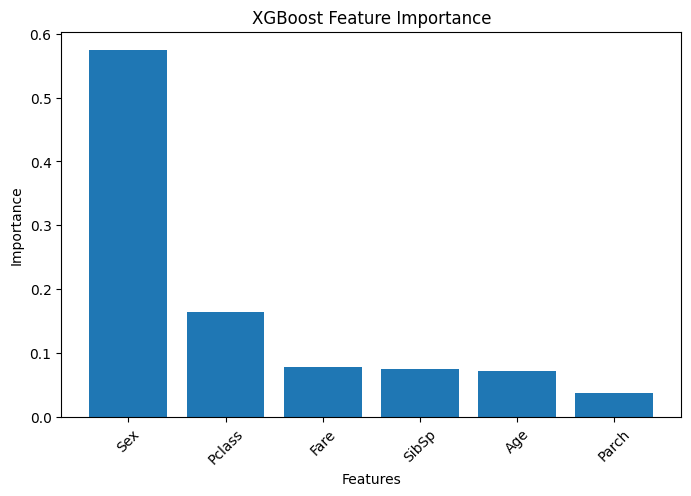

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.xticks(rotation=45)
plt.show()

4: Decision Tree Classifier for Diabetes.

In [89]:
import pandas as pd

df = pd.read_csv("/content/Diabetes_prediction.csv")

print(df.head())

   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  Diagnosis  
0  26.455940                  0.272682  20.100494          0  
1  23.910167                  0.665160  44.912281          0  
2  21.948250                  0.676022  48.247873          1  
3  24.209304                  0.289636  42.749868          0  
4  32.997477                  0.601315  32.797789          0  


In [90]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diagnosis'],
      dtype='object')


In [92]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Diagnosis                   0
dtype: int64


In [115]:
print("Zero values:")
print((df == 0).sum())

Zero values:
Pregnancies                 185
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Diagnosis                   694
dtype: int64


In [116]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    df[column] = df[column].replace(0, pd.NA)
    df[column] = df[column].fillna(df[column].median())

In [117]:
for column in zero_columns:
    df[column] = df[column].replace(0, pd.NA)


In [118]:
for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

In [119]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Diagnosis                   0
dtype: int64


In [121]:
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


In [123]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [124]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 1 0 1 0 0 1 0 0 1]


In [125]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.535
Accuracy (%): 53.5


In [127]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[91 46]
 [47 16]]


In [128]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.25806451612903225


In [129]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.25396825396825395


In [130]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.256


In [131]:
model_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model_depth3.fit(X_train, y_train)

print("Restricted Decision Tree trained successfully")

Restricted Decision Tree trained successfully


In [133]:
y_pred_depth3 = model_depth3.predict(X_test)

In [134]:
accuracy_depth3 = accuracy_score(
    y_test,
    y_pred_depth3
)

precision_depth3 = precision_score(
    y_test,
    y_pred_depth3
)

recall_depth3 = recall_score(
    y_test,
    y_pred_depth3
)

f1_depth3 = f1_score(
    y_test,
    y_pred_depth3
)

print("Max Depth = 3")
print("Accuracy:", accuracy_depth3)
print("Precision:", precision_depth3)
print("Recall:", recall_depth3)
print("F1-score:", f1_depth3)

Max Depth = 3
Accuracy: 0.68
Precision: 0.0
Recall: 0.0
F1-score: 0.0


In [135]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Normal Decision Tree": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],

    "Max Depth = 3": [
        accuracy_depth3,
        precision_depth3,
        recall_depth3,
        f1_depth3
    ]
})

print(comparison)

      Metric  Normal Decision Tree  Max Depth = 3
0   Accuracy              0.535000           0.68
1  Precision              0.258065           0.00
2     Recall              0.253968           0.00
3   F1-score              0.256000           0.00


In [137]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
4                   Insulin    0.199168
5                       BMI    0.156850
7                       Age    0.155211
2             BloodPressure    0.142573
6  DiabetesPedigreeFunction    0.134517
3             SkinThickness    0.106143
1                   Glucose    0.082300
0               Pregnancies    0.023237


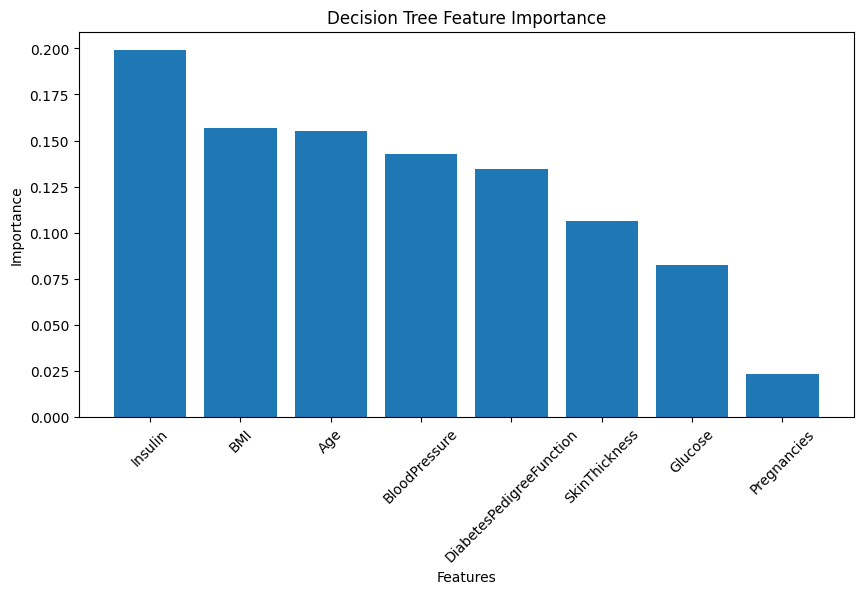

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.xticks(rotation=45)
plt.show()


5. Define features (X) and target variable (y)

In [139]:
import pandas as pd

df = pd.read_csv("/content/Diabetes_prediction.csv")

In [140]:
X = df.drop("Diagnosis", axis=1)

In [142]:
y = df["Diagnosis"]

In [144]:
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  
0  26.455940                  0.272682  20.100494  
1  23.910167                  0.665160  44.912281  
2  21.948250                  0.676022  48.247873  
3  24.209304                  0.289636  42.749868  
4  32.997477                  0.601315  32.797789  

Target (y):
0    0
1    0
2    1
3    0
4    0
Name: Diagnosis, dtype: int64


6. Train a DecisionTreeClassifier Model

In [145]:
from sklearn.tree import DecisionTreeClassifier

In [146]:
model = DecisionTreeClassifier(random_state=42)

In [148]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [149]:
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


7. Evaluate the Decision Tree Model

In [151]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [152]:
y_pred = model.predict(X_test)

In [153]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.535
Accuracy (%): 53.5


In [154]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[91 46]
 [47 16]]


In [155]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.25806451612903225


In [156]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.25396825396825395


In [158]:
f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.256


8. Restricted Decision Tree


In [159]:
from sklearn.tree import DecisionTreeClassifier

model_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

In [161]:
model_depth3.fit(X_train, y_train)

print("Restricted Decision Tree trained successfully.")

Restricted Decision Tree trained successfully.


In [163]:
y_pred_depth3 = model_depth3.predict(X_test)

In [164]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_depth3))

print("Precision:",
      precision_score(y_test, y_pred_depth3))

print("Recall:",
      recall_score(y_test, y_pred_depth3))

print("F1-score:",
      f1_score(y_test, y_pred_depth3))

Accuracy: 0.68
Precision: 0.0
Recall: 0.0
F1-score: 0.0


In [165]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Normal Tree": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],

    "Max Depth = 3": [
        accuracy_score(y_test, y_pred_depth3),
        precision_score(y_test, y_pred_depth3),
        recall_score(y_test, y_pred_depth3),
        f1_score(y_test, y_pred_depth3)
    ]
})

print(comparison)

      Metric  Normal Tree  Max Depth = 3
0   Accuracy     0.535000           0.68
1  Precision     0.258065           0.00
2     Recall     0.253968           0.00
3   F1-score     0.256000           0.00


In [167]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
4                   Insulin    0.199168
5                       BMI    0.156850
7                       Age    0.155211
2             BloodPressure    0.142573
6  DiabetesPedigreeFunction    0.134517
3             SkinThickness    0.106143
1                   Glucose    0.082300
0               Pregnancies    0.023237


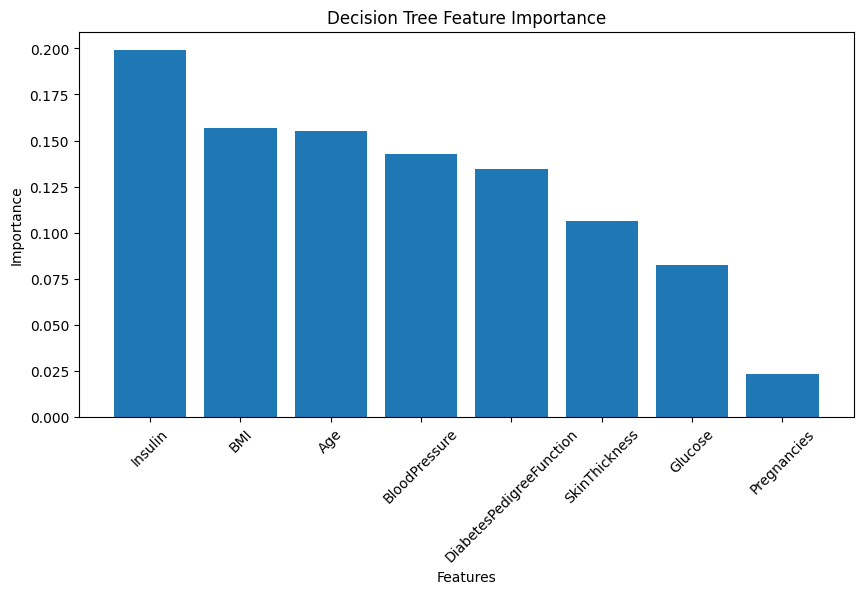

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.xticks(rotation=45)
plt.show()